# Certificados Digitais

O certificado digital é uma ferramenta essencial para comprovar a identidade de uma pessoa ou empresa em meios digitais de forma segura e confiável, sendo amplamente aceito como prova legal de identidade. Ele é baseado em criptografia assimétrica, utilizando um par de chaves (uma chave privada e uma chave pública) que garantem a autenticidade e integridade das informações sem possibilidade de duplicação.

Chave Privada: Esta chave é mantida em sigilo e só pode ser acessada pelo titular autorizado do certificado digital. Ela é utilizada para assinar documentos eletrônicos ou autenticar o usuário

#### Componentes Principais
- Chave Pública: Usada para verificar a assinatura digital e criptografar informações.
- Chave Privada: Mantida em segredo, usada para assinar documentos e descriptografar informações.
- Assinatura Digital: Garante a integridade e autenticidade do certificado, confirmando que ele não foi alterado.
- Autoridade Certificadora (CA): Entidade confiável que emite e assina digitalmente os certificados, validando a identidade do titular.


# Exemplos de utilização de Certificado Digitais com Python


## Obtendo o certificado digital associado a um domínio
Utilizamos o módulo `ssl` para se conectar a um servidor HTTPS e obter o certificado digital associado ao domínio especificado. Neste exemplo, conectamos ao servidor da Wikipedia (wikipedia.org) na porta **443**, que é a porta padrão para conexões **HTTPS**.

In [1]:
import ssl

# Definir o endereço e porta do servidor
address = ('wikipedia.org', 443)
#address = ('www.ifpr.edu.br', 443)

# Obter o certificado digital do servidor
certificate = ssl.get_server_certificate(address)

# Exibir o certificado no console
print("Certificado obtido:\n", certificate)

# Salvar o certificado em um arquivo .pem
cert_file_path = "wikipedia_cert.pem"
#cert_file_path = "wikipedia_cert.crt"

with open(cert_file_path, "w") as cert_file:
    cert_file.write(certificate)

Certificado obtido:
 -----BEGIN CERTIFICATE-----
MIIGYDCCBeagAwIBAgISBiOHxNK25oZ2fv9Uzgt+Jr3fMAoGCCqGSM49BAMDMDMx
CzAJBgNVBAYTAlVTMRYwFAYDVQQKEw1MZXQncyBFbmNyeXB0MQwwCgYDVQQDEwNZ
RTIwHhcNMjYwODA1MTkxNTQxWhcNMjYxMTAzMTkxNTQwWjAaMRgwFgYDVQQDDA8q
Lndpa2lwZWRpYS5vcmcwWTATBgcqhkjOPQIBBggqhkjOPQMBBwNCAAQtkxHkaL/l
Ams5QQdteCDatdjSBsJ0SFvd9F2J8KSepd+Dm8yKjGu8MDwe5SNoWQA9ou6xXszG
qh5Qs9MpumtJo4IE8TCCBO0wDgYDVR0PAQH/BAQDAgeAMBMGA1UdJQQMMAoGCCsG
AQUFBwMBMAwGA1UdEwEB/wQCMAAwHQYDVR0OBBYEFKwJUSPwjxWmkwfCZRkPIOTd
+UOhMB8GA1UdIwQYMBaAFLlZ8o7PIvCG0zdI/3YUGLqC2FWHMDMGCCsGAQUFBwEB
BCcwJTAjBggrBgEFBQcwAoYXaHR0cDovL3llMi5pLmxlbmNyLm9yZy8wggLtBgNV
HREEggLkMIIC4IIRKi5tLm1lZGlhd2lraS5vcmeCESoubS53aWtpYm9va3Mub3Jn
ghAqLm0ud2lraWRhdGEub3JnghEqLm0ud2lraW1lZGlhLm9yZ4IQKi5tLndpa2lu
ZXdzLm9yZ4IRKi5tLndpa2lwZWRpYS5vcmeCESoubS53aWtpcXVvdGUub3JnghIq
Lm0ud2lraXNvdXJjZS5vcmeCEyoubS53aWtpdmVyc2l0eS5vcmeCEioubS53aWtp
dm95YWdlLm9yZ4ISKi5tLndpa3Rpb25hcnkub3Jngg8qLm1lZGlhd2lraS5vcmeC
FioucGxhbmV0Lndpa2ltZWRpYS5vcmeCDyoud2lra

In [ ]:
crt_cert_file_path = "wikipedia_cert.crt"
with open(crt_cert_file_path, "w") as cert_file:
    cert_file.write(certificate)

### Dados do certificado

Vamos analisar o Certificado Digital (X.509) obtido anteriormente e extrair informações como o emissor, o assunto, o número de série, as datas de validade e o algoritmo de assinatura, além de listar as extensões associadas.

In [ ]:
from cryptography import x509
from cryptography.hazmat.backends import default_backend

# Carregar o certificado X.509 de um arquivo
with open(cert_file_path, "rb") as cert_file:
    cert_data = cert_file.read()

# Carregar o certificado usando a biblioteca cryptography
certificate = x509.load_pem_x509_certificate(cert_data, default_backend())

# Imprimir alguns dos principais campos do certificado
print("Assunto:", certificate.subject)
print("Emissor:", certificate.issuer)
print("Número de Série:", certificate.serial_number)
print("Válido de:", certificate.not_valid_before)
print("Válido até:", certificate.not_valid_after)
print("Algoritmo de Assinatura:", certificate.signature_algorithm_oid)

# Campos adicionais
print("\nExtensões:")
for ext in certificate.extensions:
    print(f" - {ext.oid}: {ext.value}")

Assunto: <Name(CN=ifpr.edu.br)>
Emissor: <Name(C=US,O=Amazon,CN=Amazon RSA 2048 M04)>
Número de Série: 16165674852799405478776531444289661731
Válido de: 2025-10-19 00:00:00
Válido até: 2026-11-17 23:59:59
Algoritmo de Assinatura: <ObjectIdentifier(oid=1.2.840.113549.1.1.11, name=sha256WithRSAEncryption)>

Extensões:
 - <ObjectIdentifier(oid=2.5.29.35, name=authorityKeyIdentifier)>: <AuthorityKeyIdentifier(key_identifier=b'\x1fR\x92aV\x82T\x7f\x81f\xd8\x1d=\n\xaa2\\\x87\xdd\x08', authority_cert_issuer=None, authority_cert_serial_number=None)>
 - <ObjectIdentifier(oid=2.5.29.14, name=subjectKeyIdentifier)>: <SubjectKeyIdentifier(digest=b"\xc8\x81I_N$`hV'\rLN\x97Y\x15w6\x97\x80")>
 - <ObjectIdentifier(oid=2.5.29.17, name=subjectAltName)>: <SubjectAlternativeName(<GeneralNames([<DNSName(value='ifpr.edu.br')>, <DNSName(value='www.ifpr.edu.br')>])>)>
 - <ObjectIdentifier(oid=2.5.29.32, name=certificatePolicies)>: <CertificatePolicies([<PolicyInformation(policy_identifier=<ObjectIdentifier(oi

/tmp/ipython-input-145483892.py:15: CryptographyDeprecationWarning: Properties that return a naïve datetime object have been deprecated. Please switch to not_valid_before_utc.
  print("Válido de:", certificate.not_valid_before)
/tmp/ipython-input-145483892.py:16: CryptographyDeprecationWarning: Properties that return a naïve datetime object have been deprecated. Please switch to not_valid_after_utc.
  print("Válido até:", certificate.not_valid_after)


## Gerando um Certificado Digital (**autoassinado**)

Um certificado digital autoassinado é um certificado gerado e assinado pela própria entidade que o utiliza, em vez de ser assinado por uma Autoridade Certificadora (CA). Isso significa que a entidade que emite o certificado também o valida, o que difere dos certificados assinados por CAs, onde uma terceira parte confiável verifica e atesta a identidade da entidade.

* **Certificado Raiz**, é um certificado especial emitido por uma Autoridade Certificadora Raiz (Root CA), que serve como o ponto inicial (ou raiz) de uma cadeia de confiança em sistemas de certificação digital.

* **Certificado Raiz é Autoassinado**: A própria CA raiz assina o seu próprio certificado, já que não há uma entidade superior para validar sua identidade. Por isso, todo certificado raiz é um tipo de certificado autoassinado.

No exemplo abaixo vamos gerar um par de chaves criptográficas e criar um certificado digital (autoassinado) associado a esse par de chaves.

In [ ]:
from cryptography.hazmat.backends import default_backend
from cryptography.hazmat.primitives.asymmetric import rsa
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.primitives import hashes
from cryptography.x509 import Name, CertificateBuilder, SubjectAlternativeName
import cryptography.x509 as x509
from datetime import datetime, timedelta

# Gerar uma chave privada
private_key = rsa.generate_private_key(
    public_exponent=65537,
    key_size=2048,
    backend=default_backend()
)

# Salvar a chave privada em um arquivo
with open("private_key_RaizIFPR.pem", "wb") as f:
    f.write(private_key.private_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PrivateFormat.TraditionalOpenSSL,
        encryption_algorithm=serialization.NoEncryption()
    ))

# Gerar a chave pública
public_key = private_key.public_key()

# Criar um certificado autoassinado
subject = x509.Name([
    x509.NameAttribute(x509.oid.NameOID.COUNTRY_NAME, u"BR"),
    x509.NameAttribute(x509.oid.NameOID.STATE_OR_PROVINCE_NAME, u"PR"),
    x509.NameAttribute(x509.oid.NameOID.LOCALITY_NAME, u"Cascavel"),
    x509.NameAttribute(x509.oid.NameOID.ORGANIZATION_NAME, u"IFPR"),
    x509.NameAttribute(x509.oid.NameOID.EMAIL_ADDRESS, u"ifpr.cascavel@ifpr.edu.br"),
    x509.NameAttribute(x509.oid.NameOID.BUSINESS_CATEGORY, u"Educacao"),
    x509.NameAttribute(x509.oid.NameOID.COMMON_NAME, u"ifpr.edu.br"),
])

issuer = subject  # Para autoassinado, o emissor é o mesmo que o sujeito

# Definir a validade do certificado
valid_from = datetime.utcnow()
valid_until = valid_from + timedelta(days=365*2)

# Criar o certificado
certificate = CertificateBuilder().subject_name(
    subject
).issuer_name(
    issuer
).public_key(
    public_key
).serial_number(
    x509.random_serial_number()
).not_valid_before(
    valid_from
).not_valid_after(
    valid_until
).add_extension(
    SubjectAlternativeName([x509.DNSName(u"alternativo.ifpr.edu.br")]),
    critical=False,
).sign(private_key, hashes.SHA256(), default_backend())

# Salvar o certificado em um arquivo
with open("certificado_RaizIFPR_teste.pem", "wb") as f:
    f.write(certificate.public_bytes(serialization.Encoding.PEM))

print("Chaves e certificado gerados com sucesso!")


Chaves e certificado gerados com sucesso!


/tmp/ipython-input-1818850239.py:41: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  valid_from = datetime.utcnow()


In [ ]:
with open("certificado_RaizIFPR_teste.cer", "wb") as f:
    f.write(certificate.public_bytes(serialization.Encoding.PEM))

### Agora vamos criar um cerficado assinado pelo certificado que criamos no passo anterior.

* Neste exemplo gostaria de simular que estaríamos criando um certificodo pessoal (professor Thiago B. Lo) assianado pela nossa CA, que seria o IFPR.

In [ ]:
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.primitives import hashes
from cryptography.x509 import CertificateBuilder, Name, SubjectAlternativeName, KeyUsage
import cryptography.x509 as x509
from datetime import datetime, timedelta

# Carregar a chave privada da CA
with open("private_key_RaizIFPR.pem", "rb") as f:
    ca_private_key = serialization.load_pem_private_key(
        f.read(),
        password=None,
    )

# Carregar o certificado da CA
with open("certificado_RaizIFPR_teste.pem", "rb") as f:
    ca_certificate = x509.load_pem_x509_certificate(
        f.read(),
        default_backend()
    )

# Criar um novo par de chaves para o certificado assinado
new_private_key = rsa.generate_private_key(
    public_exponent=65537,
    key_size=2048,
    backend=default_backend()
)

# Salvar a nova chave privada em um arquivo (sem criptografia)
with open("private_key_ThiagoLo.pem", "wb") as f:
    f.write(new_private_key.private_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PrivateFormat.TraditionalOpenSSL,
        encryption_algorithm=serialization.NoEncryption()
    ))

# Gerar a chave pública para o novo certificado
new_public_key = new_private_key.public_key()

# Criar o novo certificado
new_subject = x509.Name([
    x509.NameAttribute(x509.oid.NameOID.COUNTRY_NAME, u"BR"),
    x509.NameAttribute(x509.oid.NameOID.STATE_OR_PROVINCE_NAME, u"PR"),
    x509.NameAttribute(x509.oid.NameOID.LOCALITY_NAME, u"Cascavel"),
    x509.NameAttribute(x509.oid.NameOID.ORGANIZATION_NAME, u"IFPR"),
    x509.NameAttribute(x509.oid.NameOID.EMAIL_ADDRESS, u"thiago.lol@ifpr.edu.br"),
    x509.NameAttribute(x509.oid.NameOID.BUSINESS_CATEGORY, u"Educacao"),
    x509.NameAttribute(x509.oid.NameOID.TITLE, u"Professor"),
    x509.NameAttribute(x509.oid.NameOID.COMMON_NAME, u"Thiago Berticelli Lo"),
])

# Definir a validade do novo certificado
valid_from_new = datetime.utcnow()
valid_until_new = valid_from_new + timedelta(days=365)

# Criar a extensão KEY_USAGE
key_usage = KeyUsage(
    digital_signature=True,  # Permite a assinatura digital
    content_commitment=False,  # Não permite compromisso de conteúdo
    key_encipherment=True,  # Permite a criptografia de chaves
    data_encipherment=False,  # Não permite a criptografia de dados
    key_agreement=False,  # Não permite acordo de chave
    key_cert_sign=False,  # Não permite assinatura de certificados
    crl_sign=False,  # Não permite assinatura de CRL (Lista de Certificados Revogados)
    encipher_only=False,  # Não permite somente cifragem
    decipher_only=False  # Não permite somente decifração
)


# Criar o novo certificado assinado pela CA
new_certificate = CertificateBuilder().subject_name(
    new_subject
).issuer_name(
    ca_certificate.subject  # O emissor é o certificado da CA
).public_key(
    new_public_key
).serial_number(
    x509.random_serial_number()
).not_valid_before(
    valid_from_new
).not_valid_after(
    valid_until_new
).add_extension(
    key_usage,
    critical=True,  # A extensão é crítica, ou seja, deve ser verificada para validar o certificado
).sign(ca_private_key, hashes.SHA256(), default_backend())  # Assinar com a chave privada da CA

# Salvar o novo certificado em um arquivo
with open("certificado_ThiagoLo.pem", "wb") as f:
    f.write(new_certificate.public_bytes(serialization.Encoding.PEM))

print("Novo certificado assinado pela CA gerado com sucesso!")


Novo certificado assinado pela CA gerado com sucesso!


/tmp/ipython-input-1862754244.py:52: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  valid_from_new = datetime.utcnow()


In [ ]:
# Salvar o novo certificado em um arquivo
with open("certificado_ThiagoLo.cer", "wb") as f:
    f.write(new_certificate.public_bytes(serialization.Encoding.PEM))

## Validando a cadeia de Certificados Digitais

 Neste exemplo vamos validar uma cadeia de certificado X.509, que é fundamental para garantir a autenticidade e integridade de uma comunicação digital segura.

 - A validação de uma cadeia de certificados envolve verificar a assinatura digital de cada certificado, garantindo que o certificado foi emitido por uma autoridade confiável e que a cadeia de confiança está completa.

- Além disso, vamos validar do Nome Comum (CN) do certificado e fazer a verificação do uso da chave pública, para garantir que o certificado possa ser utilizado corretamente para assinaturas digitais.


In [ ]:
from cryptography import x509
from cryptography.hazmat.backends import default_backend
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.primitives.asymmetric import padding

def load_certificates(cert_paths):
    """Carrega uma lista de certificados a partir de arquivos PEM."""
    certificates = []
    for path in cert_paths:
        with open(path, "rb") as f:
            cert = x509.load_pem_x509_certificate(f.read(), default_backend())
            certificates.append(cert)
    return certificates

def validate_chain(certificates, expected_cn=None):
    """Valida uma cadeia de certificados e faz verificações adicionais."""
    for i in range(len(certificates) - 1):
        current_cert = certificates[i]
        issuer_cert = certificates[i + 1]

        # Verifique o Nome Comum (CN) se um valor esperado for fornecido
        if expected_cn:
            subject = current_cert.subject.get_attributes_for_oid(x509.NameOID.COMMON_NAME)
            if not subject or subject[0].value != expected_cn:
                print(f"Validação do CN falhou para o certificado {i + 1}: esperado '{expected_cn}', encontrado '{subject[0].value}' se presente.")
                return False

        # Verifique o uso da chave (se a chave pública é adequada para o uso esperado)
        key_usage = current_cert.extensions.get_extension_for_oid(x509.oid.ExtensionOID.KEY_USAGE)
        if key_usage:
            if not key_usage.value.digital_signature:
                print(f"O certificado {i + 1} não pode ser usado para assinatura digital.")
                return False

        # Verifique a assinatura do certificado atual usando o certificado emissor
        try:
            issuer_cert.public_key().verify(
                current_cert.signature,
                current_cert.tbs_certificate_bytes,
                padding.PKCS1v15(),
                current_cert.signature_hash_algorithm
            )
            print(f"Certificado {i + 1} é válido e assinado pelo certificado {i}.")
        except Exception as e:
            print(f"Validação do certificado {i + 1} falhou: {str(e)}")
            return False

    return True

################################################################################
################################################################################

# Lista dos caminhos para os arquivos dos certificados na cadeia
cert_paths = [
    "certificado_ThiagoLo.pem",   # Certificado de folha (a ser validado)
    #"intermediate.pem",  # Certificado intermediário (caso tenha)
    "certificado_RaizIFPR_teste.pem"          # Certificado raiz
    #'wikipedia_cert.pem'
]

# Carregar os certificados
certificates = load_certificates(cert_paths)

# Validação do CN específico (opcional)
CN_esperado = "Thiago Berticelli Lo"

# Validar a cadeia de certificados
if validate_chain(certificates, expected_cn=CN_esperado):
    print("A cadeia de certificados é válida.")
else:
    print("A cadeia de certificados é inválida.")


Validação do certificado 1 falhou: 
A cadeia de certificados é inválida.


Legal! Agora que validamos o certificado do prof. Thiago Ló, podemo mandar uma mensagem secreta!

In [ ]:
from cryptography import x509
from cryptography.hazmat.backends import default_backend
from cryptography.hazmat.primitives.asymmetric import rsa, padding
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives import serialization


cert_path = "certificado_ThiagoLo.pem"  # Caminho para o certificado
message = b'Professor, voce corrigiu a prova?.'

with open(cert_path, "rb") as cert_file:
  cert_data = cert_file.read()
  cert = x509.load_pem_x509_certificate(cert_data, default_backend())

# Obter a chave pública do certificado
public_key = cert.public_key()

padding_config = padding.OAEP(
                    mgf=padding.MGF1(algorithm=hashes.SHA256()),
                    algorithm=hashes.SHA256(),
                    label=None, )

ciphertext = public_key.encrypt(
                     plaintext=message,
                     padding=padding_config,
)

# Exibir a mensagem cifrada
print("Mensagem cifrada:", ciphertext.hex())



Mensagem cifrada: 28e835d307674f812eeffcde62bc7e11fef6049eba5cfb654e5d79b2ae191be77b09bb5195fd329a8b5abeb5b5e2aef59f44d5ce8efe5d536ca92cf09a0fab55e7711a90d5ed7794596dfd3793cb9976954f365d5d3a390e6e650ea3815f95d4de3bd136ffa608407aa8b38ba36fc8b74702613757b4c8dd80ec5a7f3666c14609244b04ba46b23e59727a8496a1609b998897df0be5bb04160712f993ba7ef5781d09de61e87b0059ca9d7132f7b6ace5590d1039df63990c7deac7b6894d17b5a8a7b196eaf14ddcd251cc6cd8ea0d5d1599c09b34c877627f7eb8fb4b05d5f4e666554948bb8a45ae7eec1de2f0526a218f67cce6d55beac2981b0680c75b


# Trabalho de implementação

## Implementação da Autenticação do Servidor (Challenge-Response)

Implementar a lógica de autenticação do servidor pelo cliente, simulando o processo de Desafio-Resposta baseado em criptografia de chave pública, utilizando certificados digitais.

- Para a simulação você deve gerar o Certificado Raiz (AC) e o Certificado do Servidor, assinado pela CA Raiz.

O processo de autenticação do Servidor pelo Cliente, utilizando certificados digitais, segue as seguintes etapas principais:

1. Início e Envio do Certificado
  - O Cliente inicia a comunicação.
  - O Servidor envia seu Certificado ($\text{Cert}_{\text{SVR}}$) ao Cliente.

2. Validação da Confiança no Certificado (Ações do Cliente)

> Esta é a fase crítica onde o Cliente determina se o $\text{Cert}_{\text{SVR}}$ é confiável, utilizando a Chave Pública da CA (Autoridade Certificadora) que ele possui.
  - Verificação da Cadeia de Confiança: O Cliente verifica a assinatura digital do $\text{Cert}_{\text{SVR}}$ usando a Chave Pública da CA de confiança. Se a assinatura for inválida, o certificado é rejeitado.
  - Verificação de Prazo: O Cliente confirma que o certificado está dentro do seu período de validade (Not Before e Not After).
  - Verificação da Identidade (CN): O Cliente garante que o campo Common Name (CN) do certificado corresponde exatamente ao nome (hostname ou IP) do Servidor que ele esperava conectar.
  - Extração da Chave Pública: Se todas as verificações acima forem bem-sucedidas, o Cliente extrai a Chave Pública do Servidor ($\text{Pub}_{\text{SVR}}$) do certificado.

3. Prova de Posse da Chave ($\text{Nonce}$ Challenge)
  
> O Cliente utiliza a $\text{Pub}_{\text{SVR}}$ validada para provar que o Servidor é quem diz ser.
  - Geração do Desafio (Cliente): O Cliente gera um valor aleatório único ($\text{Nonce}$).
  - Criptografia (Cliente): O Cliente criptografa o $\text{Nonce}$ usando a $\text{Pub}_{\text{SVR}}$ e o envia ao Servidor.
  - Descriptografia (Servidor): O Servidor recebe a mensagem e a descriptografa usando a Chave Privada ($\text{Priv}_{\text{SVR}}$) correspondente. Este é o único ator que pode fazer isso.
  - Resposta e Verificação (Servidor $\to$ Cliente): O Servidor envia o $\text{Nonce}$ descriptografado de volta. O Cliente compara a resposta com o $\text{Nonce}$ original. Se forem idênticos, a Autenticação do Servidor está completa.


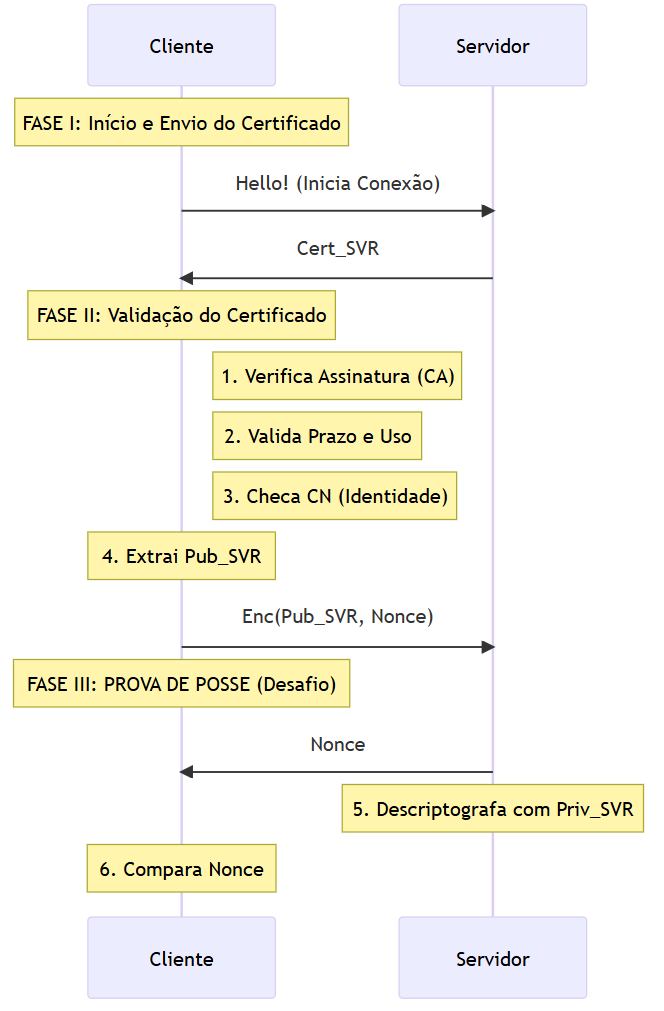

```mermaid
sequenceDiagram
    participant C as Cliente
    participant S as Servidor

    Note over C: FASE I: Início e Envio do Certificado
    
    C->>S: Hello! (Inicia Conexão)
    
    S->>C: Cert_SVR
    Note over C: FASE II: Validação do Certificado
   
    Note right of C: 1. Verifica Assinatura (CA)
    Note right of C: 2. Valida Prazo e Uso
    Note right of C: 3. Checa CN (Identidade)
    
    Note over C: 4. Extrai Pub_SVR
        
    C->>S: Enc(Pub_SVR, Nonce)
    Note over C: FASE III: PROVA DE POSSE (Desafio)
         
    S->>C: Nonce
    Note over S: 5. Descriptografa com Priv_SVR
                
    Note over C: 6. Compara Nonce
```